In [1]:
using ITensors, ITensorMPS, Plots, Statistics, StatsBase, GLM, DataFrames, Kneedle, SavitzkyGolay, JLD2



In [2]:
data_path = joinpath(@__DIR__, "EPS_BD_data.jld2")

if isfile(data_path)
    data = load(data_path)
    avg_matrix = data["avg_matrix"]     # Average bond dimensions
    err_matrix = data["err_matrix"]     # Standard deviations
    N_range = data["N_range"]           # System sizes (x-axis)
    sigma_values = data["sigma_values"] # Disorder strengths (curves)
    vn_avg = data["vn_avg"]
    s05_avg = data["s05_avg"]
    s0_avg = data["s0_avg"]
    spectra_avg = data["spectra_avg"]   # 3D Array: [N_idx, sigma_idx, k]
    println("Data successfully loaded!")
else
    println("Data file not found at: $data_path")
end


Data successfully loaded!


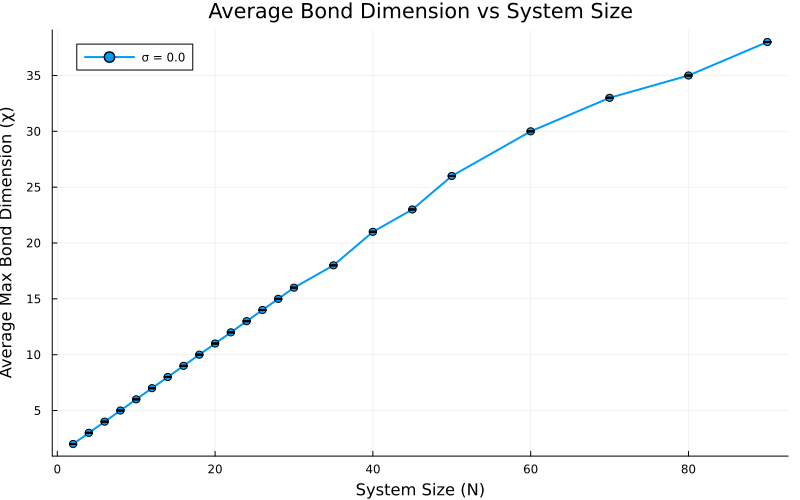

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_EPS_BD_and_bounded\\images\\BD_scaling.png"

In [3]:
p_bd = plot(
    title = "Average Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Average Max Bond Dimension (χ)",
    legend = :topleft,
    grid = true,
    size = (800, 500)
)

sigma_values = [0.0]

for (j, σ) in enumerate(sigma_values)
    valid_indices = findall(x -> x != 0.0, avg_matrix[:, j])
    
    if !isempty(valid_indices)
        plot!(p_bd, 
              N_range[valid_indices], 
              avg_matrix[valid_indices, j], 
              yerr = err_matrix[valid_indices, j], # Add error bars from simulation
              label = "σ = $σ", 
              marker = :circle, 
              linewidth = 2)
    end
end

display(p_bd)
savefig(p_bd, joinpath(@__DIR__, "images", "BD_scaling.png"))

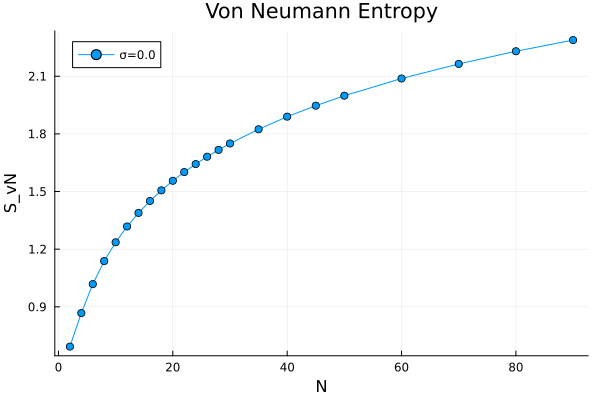

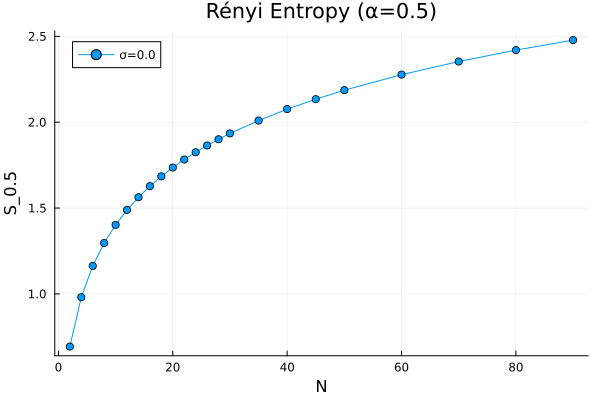

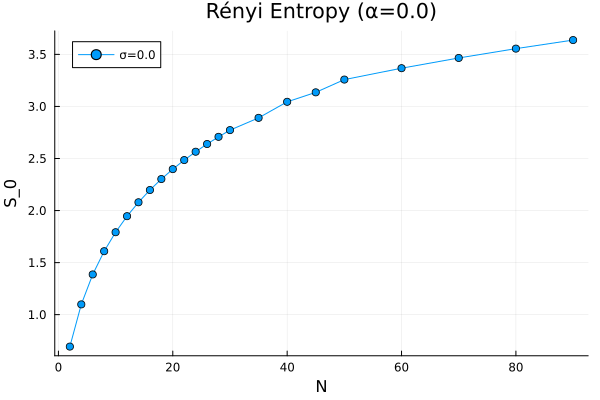

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_EPS_BD_and_bounded\\images\\Renyi_Entropy_alpha_0.png"

In [4]:
p_vn = plot(title="Von Neumann Entropy", xlabel="N", ylabel="S_vN", legend=:topleft, grid=true)
for (j, σ) in enumerate(sigma_values)
    valid_indices = findall(x -> x != 0.0, vn_avg[:, j])
    if !isempty(valid_indices)
        plot!(p_vn, N_range[valid_indices], vn_avg[valid_indices, j], label="σ=$σ", marker=:circle)
    end
end
display(p_vn)
savefig(p_vn, joinpath(@__DIR__, "images", "Von_Neumann_Entropy.png"))

p_r05 = plot(title="Rényi Entropy (α=0.5)", xlabel="N", ylabel="S_0.5", legend=:topleft, grid=true)
for (j, σ) in enumerate(sigma_values)
    valid_indices = findall(x -> x != 0.0, s05_avg[:, j])
    if !isempty(valid_indices)
        plot!(p_r05, N_range[valid_indices], s05_avg[valid_indices, j], label="σ=$σ", marker=:circle)
    end
end
display(p_r05)
savefig(p_r05, joinpath(@__DIR__, "images", "Renyi_Entropy_alpha_0.5.png"))

p_r0 = plot(title="Rényi Entropy (α=0.0)", xlabel="N", ylabel="S_0", legend=:topleft, grid=true)
for (j, σ) in enumerate(sigma_values)    
    valid_indices = findall(x -> x != 0.0, s0_avg[:, j])
    if !isempty(valid_indices)
        plot!(p_r0, N_range[valid_indices], s0_avg[valid_indices, j], label="σ=$σ", marker=:circle)
    end
end
display(p_r0)
savefig(p_r0, joinpath(@__DIR__, "images", "Renyi_Entropy_alpha_0.png"))


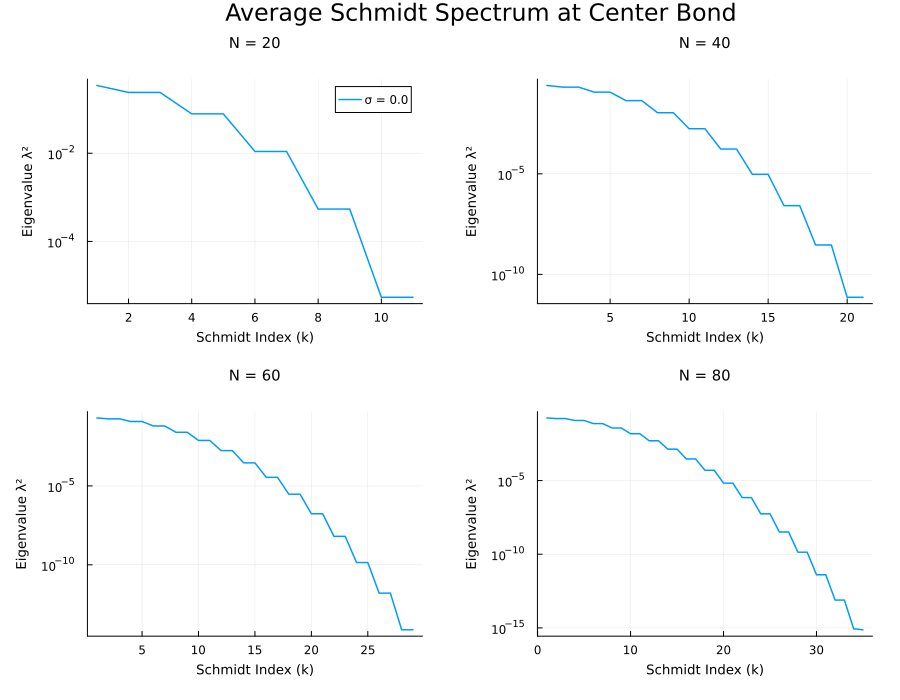

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_EPS_BD_and_bounded\\images\\spectra_2x2.png"

In [5]:
# Target parameters for the 2x2 grid plot
target_Ns = [20, 40, 60, 80]
target_sigmas = [0.0, 0.00001, 0.002]

# Create the 2x2 plot layout
p_spectra = plot(
    layout = (2, 2),
    size = (900, 700),
    plot_title = "Average Schmidt Spectrum at Center Bond",
    titlefont = font(10),
    guidefont = font(9),
    margin = 5Plots.mm
)

for (idx, target_N) in enumerate(target_Ns)
    n_idx = findfirst(==(target_N), N_range)
    
    if isnothing(n_idx)
        println("Warning: N=$target_N not found in N_range. Skipping subplot.")
        continue
    end
    
    for target_sigma in target_sigmas
        sig_idx = findfirst(==(target_sigma), sigma_values)
        
        if isnothing(sig_idx)
            println("Warning: σ=$target_sigma not found in sigma_values.")
            continue
        end
        
        # Extract the spectrum for this N and σ
        # Dimension is [N_idx, sigma_idx, k_index]
        spectrum = spectra_avg[n_idx, sig_idx, :]
        
        # Filter out the trailing zeros and sort in descending order
        # We filter values below 10^{-18} to handle numerical noise
        valid_spectrum = sort(filter(x -> x > 1e-18, spectrum), rev=true)
        
        if !isempty(valid_spectrum)
            plot!(p_spectra[idx], 
                  1:length(valid_spectrum), 
                  valid_spectrum, 
                  yaxis = :log10, # Log scale for Schmidt spectra
                #   marker = :circle, 
                  markersize = 3,
                  linewidth = 1.5,
                  label = "σ = $target_sigma",
                  title = "N = $target_N",
                  xlabel = "Schmidt Index (k)",
                  ylabel = "Eigenvalue λ²",
                  legend = (idx == 1 ? :topright : false), # Only put legend in first subplot
                  grid = true)
        end
    end
end

display(p_spectra)
savefig(p_spectra, joinpath(@__DIR__, "images", "spectra_2x2.png"))